In [1]:
import pandas as pd
import pingouin as pg
import numpy as np
import scipy.stats as st
from matplotlib import pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from itertools import combinations

/opt/conda/lib/python3.9/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
users_test = pd.read_csv("csv_data/users_test.csv", sep=";")
users_control_1 = pd.read_csv("csv_data/users_control_1.csv", sep=";")
users_control_2 = pd.read_csv("csv_data/users_control_2.csv", sep=";")
transactions_test = pd.read_csv(
    "csv_data/transactions_test.csv", sep=";", parse_dates=["joined_at", "paid_at"]
)
transactions_control_1 = pd.read_csv(
    "csv_data/transactions_control_1.csv", sep=";", parse_dates=["joined_at", "paid_at"]
)
transactions_control_2 = pd.read_csv(
    "csv_data/transactions_control_2.csv", sep=";", parse_dates=["joined_at", "paid_at"]
)

### Сначала подумаем что мы изменили?

1. Изменили цену премиум-подписки

2. Только для новых пользователей

3. Только при оплате через две новые платежные системы

**Trial price не изменился**

### На что повлияет?

- конверси в премиум подписку
- выручку
- ARPU
- ARPPU 

In [3]:
# Проведем EDA - разведочный анализ данных.
# 1. Посмотрим размер данных, типы, наличие пустых значений, дубликатов
# 2. Посмотрим на аномалии и наличие выбросов

In [4]:
# Сначала объединим данные для удобства, обозначив кто к какой группе принадлежит

users_test["group"] = "test"
users_control_1["group"] = "control_1"
users_control_2["group"] = "control_2"

transactions_test["group"] = "test"
transactions_control_1["group"] = "control_1"
transactions_control_2["group"] = "control_2"

In [5]:
users = pd.concat([users_test, users_control_1, users_control_2])
transactions = pd.concat(
    [transactions_test, transactions_control_1, transactions_control_2]
)

In [6]:
users.columns

Index(['uid', 'age', 'attraction_coeff', 'coins', 'country', 'visit_days',
       'gender', 'age_filter_start', 'age_filter_end', 'views_count',
       'was_premium', 'is_premium', 'total_revenue', 'group'],
      dtype='object')

In [7]:
transactions.columns

Index(['uid', 'country', 'joined_at', 'paid_at', 'revenue', 'payment_id',
       'from_page', 'product_type', 'group'],
      dtype='object')

In [8]:
print("Размеры исходных таблиц: ")
print(transactions.shape)
print(users.shape)

Размеры исходных таблиц: 
(1608, 9)
(12912, 14)


In [9]:
print("Информация по таблице users: ")
print(users.info())
print()
print("Информация по таблице transactions: ")
print(transactions.info())

Информация по таблице users: 
<class 'pandas.core.frame.DataFrame'>
Int64Index: 12912 entries, 0 to 4263
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   uid               12912 non-null  int64  
 1   age               12912 non-null  int64  
 2   attraction_coeff  12912 non-null  int64  
 3   coins             170 non-null    float64
 4   country           12912 non-null  object 
 5   visit_days        8894 non-null   object 
 6   gender            12912 non-null  int64  
 7   age_filter_start  12912 non-null  int64  
 8   age_filter_end    12912 non-null  int64  
 9   views_count       12912 non-null  int64  
 10  was_premium       1255 non-null   float64
 11  is_premium        540 non-null    float64
 12  total_revenue     12912 non-null  int64  
 13  group             12912 non-null  object 
dtypes: float64(3), int64(8), object(3)
memory usage: 1.5+ MB
None

Информация по таблице transactions: 
<clas

In [10]:
print("Пропущенные значения в таблице users")
print(users.isna().sum())
print()
print("Пропущенные значения в таблице transactions")
print(transactions.isna().sum())
# Здесь видно, что во второй таблице 630 значений пропущены везде,
# значит у нас 630 просто пустых строк, которые нужно удалить.

Пропущенные значения в таблице users
uid                     0
age                     0
attraction_coeff        0
coins               12742
country                 0
visit_days           4018
gender                  0
age_filter_start        0
age_filter_end          0
views_count             0
was_premium         11657
is_premium          12372
total_revenue           0
group                   0
dtype: int64

Пропущенные значения в таблице transactions
uid             630
country         630
joined_at       630
paid_at         630
revenue         630
payment_id      630
from_page       630
product_type    630
group             0
dtype: int64


In [11]:
# В первой таблице отсутствие значения озночает, что этого не было у пользователя
# (внутренней валюты, премиума и т.д.),
# поэтому можно безболезненно заполнить значения нулями
users["coins"] = users["coins"].fillna(0)
users["was_premium"] = users["was_premium"].fillna(0)
users["is_premium"] = users["is_premium"].fillna(0)

In [12]:
# Избавляемся от пропусков во второй таблице
transactions = transactions.dropna()

In [13]:
# Отлично, теперь все чисто!
transactions.isna().sum()

uid             0
country         0
joined_at       0
paid_at         0
revenue         0
payment_id      0
from_page       0
product_type    0
group           0
dtype: int64

In [14]:
# Важные этап - посмотреть на размер групп и распределение.
print("Размер групп (users):")
print(users.groupby("group").size())
print()
print("Распределение по странам и группам:")
print(users.groupby(["group", "country"]).size())
print()
print("Распределение по полу и группам:")
print(users.groupby(["group", "gender"]).size())
# Имеем почти одинаковые группы, мужчин больше женщин (95% и 5% соответственно),
# группы по странам распределены, на первый взгляд, корректно
# (в более развитых / густонаселенных странах пользователей больше)

Размер групп (users):
group
control_1    4340
control_2    4264
test         4308
dtype: int64

Распределение по странам и группам:
group      country                       
control_1  Algeria                              2
           Argentina                          389
           Armenia                              1
           Australia                           50
           Belgium                            108
                                             ... 
test       United Arab Emirates               226
           United Kingdom (Great Britain)     169
           United States of America          1450
           Uruguay                              1
           Uzbekistan                           1
Length: 136, dtype: int64

Распределение по полу и группам:
group      gender
control_1  0          182
           1         4158
control_2  0          195
           1         4069
test       0          202
           1         4106
dtype: int64


In [15]:
# Проверим статистические различие между группами по важным характеристикам, начнем с возраста:
table = pd.crosstab(users["group"], users["gender"])
chi2, p, dof, expected_freq = st.chi2_contingency(table)
print(p)
# Имеем p-vaalue > 0.05, следовательно, группы статистически не различаются по полу
# Выбрали ХИ квадрат, так как две еременные категориальные

0.5075117213177165


In [16]:
# Так как приложение для дейтинга, стоит проверить возраст и оставить опиматьные значния от 18 лет.
users.groupby("group")["age"].describe()

,count,mean,std,min,25%,50%,75%,max
group,,,,,,,,
control_1,4340.0,32.095392,10.257466,16.0,24.0,30.0,38.0,99.0
control_2,4264.0,32.046201,10.170721,16.0,25.0,30.0,38.0,99.0
test,4308.0,31.889276,10.245287,16.0,25.0,30.0,38.0,99.0


In [17]:
users = users[(users.age >= 18)]

In [18]:
print(pg.normality(data=users, dv="age", group="group"))
print()
print(
    st.kruskal(
        users[users.group == "test"]["age"],
        users[users.group == "control_1"]["age"],
        users[users.group == "control_2"]["age"],
    )
)

# При ненормальном распределении всех групп, используем непараметрический аналог ANOVA для 3+ независимыз групп.
# Получили p-value = 0.589 > 0.05 => значимых различий распределений у групп по возрасту не выявлено.

                  W          pval  normal
group                                    
test       0.918580  6.941769e-43   False
control_1  0.922938  3.680693e-42   False
control_2  0.931173  3.560777e-40   False

KruskalResult(statistic=1.0599272723830144, pvalue=0.5886263739859194)


In [19]:
# По условию соответствуют рамкам, все в порядке
print(users["attraction_coeff"].describe())
print()
print("По группам:")
print(users.groupby("group")["attraction_coeff"].describe())

count    12607.000000
mean       318.850321
std        323.610962
min          0.000000
25%          0.000000
50%        250.000000
75%        537.000000
max       1000.000000
Name: attraction_coeff, dtype: float64

По группам:
            count        mean         std  min  25%    50%    75%     max
group                                                                    
control_1  4236.0  315.513692  321.355496  0.0  0.0  250.0  529.0  1000.0
control_2  4168.0  321.617562  326.121834  0.0  0.0  250.0  555.0  1000.0
test       4203.0  319.468951  323.423894  0.0  0.0  250.0  524.5  1000.0


In [20]:
# Посмотрим еще на просмотры
print(users["views_count"].describe())
print()
print("По группам:")
print(users.groupby("group")["views_count"].describe())
# Зесь тоже видимых логических ошибок не было замечено

count    12607.000000
mean        45.972079
std        264.414567
min          0.000000
25%          1.000000
50%          6.000000
75%         21.000000
max      16157.000000
Name: views_count, dtype: float64

По группам:
            count       mean         std  min  25%  50%   75%      max
group                                                                 
control_1  4236.0  44.338527  204.787367  0.0  1.0  6.0  22.0   4953.0
control_2  4168.0  45.697457  321.584396  0.0  1.0  6.0  20.0  16157.0
test       4203.0  47.890792  254.786956  0.0  1.0  6.0  23.0   7110.0


In [21]:
transactions = transactions[transactions["paid_at"] >= transactions["joined_at"]]
# Сразу убираем ошибочные строки с датами

In [22]:
transactions = transactions[transactions.uid.isin(users.uid)]
# уберем также те транзакции, которые не пренадлежат пользователям

In [23]:
users["total_revenue"].sum() == transactions["revenue"].sum()
# Суммы не совпадают, будем спротреть по второй таблице, т.к. это первичный источник

False

In [24]:
print("Размер групп (transactions):")
print(transactions.groupby("group").size())
print()
print("Распределение по странам и группам:")
print(transactions.groupby(["group", "country"]).size())
print()
print("Распределение по типу продукта и группам:")
print(transactions.groupby(["group", "product_type"]).size())
# Здесь тоже по группам все оказалось вполне себе однородно, в том числе по типам продукта.

Размер групп (transactions):
group
control_1    319
control_2    265
test         222
dtype: int64

Распределение по странам и группам:
group      country                       
control_1  Argentina                         19
           Australia                          3
           Belgium                            3
           Canada                            11
           Chile                             14
           France                            33
           Germany                            7
           India                              2
           Israel                            19
           Italy                             56
           Portugal                           3
           Russian Federation                 3
           Spain                             13
           Switzerland                        3
           Turkey                             4
           United Arab Emirates               9
           United Kingdom (Great Britain)    23
      

In [25]:
# Распределение типов продукта по группам
transactions.groupby(["group", "product_type"])["uid"].nunique().unstack()

product_type,coins,other_type,premium_no_trial,trial_premium
group,,,,
control_1,57,27,88,51
control_2,57,27,91,32
test,48,17,59,46


In [26]:
# Добавим еще флаг покупки премиума, для анализа и визуализации
premium_uids = transactions[transactions["product_type"] == "premium_no_trial"][
    "uid"
].unique()

users["premium_buyer"] = users["uid"].isin(premium_uids).astype(int)

In [27]:
print("Размеры таблиц после проведенного первичного исследования: ")
print("Users:", users.shape)
print("Transactions:", transactions.shape)

Размеры таблиц после проведенного первичного исследования: 
Users: (12607, 15)
Transactions: (806, 9)


# ТАБЛИЦА USERS

## Группы сопоставимы, размеры практически не отличаются, по полу распределены одинаково

## attraction_coeff 
- среднее =~ 319, медиана 250, сильно скошено вправо (max = 1000, 75% = 537)
- т.е. есть несколько суперпопулярных пользователей

## views_count 
- среднее =~46, медиана 6, max = 16157 , очень сильный разброс, почти все активны с маленьким количеством просмотров 

### Примечание о данных
Данные не нормальные, для дохода и конверсии это нормально, но для статистических тестов лучше использовать непараметрические методы
Группы статистически не различаются по полу и возрасту (p > 0.05), что позволяет считать рандомизацию корректной.

---

# ТАБЛИЦА TRANSACTIONS

## Количество пользователей, оплативших премиум 
- test = 222
- control_1 = 319
- control_2 = 265

## Пробные премиум-периоды 
- в test выше, чем в control_2 (47 против 32)
- но меньше, чем в control_1 (51)

## Общее количество транзакций 
меньше в тестовой группе, что ожидаемо, так как стоимость подписки была изменена

## Предварительная обработка данных

При проведении первичного просмотра данных были удалены:
- строки с ошибочным распределением времени (transactions['paid_at'] < transactions['joined_at'])
- транзакции, которые не имели пользователей, т.к. это не даст нам никакой нужной информации

---

## Итоги первичного анализа

После проведенного первичного исследования данных, прикидки их размера, распределения отдельных показателей, чистки ненужных значений — можно начинать основной анализ результатов А/B тестирования.

In [28]:
# Для упрощения последующего анализа, оставим данные только по странам, где мы можем отследить все три группы

In [29]:
valid_countries = users.groupby("country")["group"].nunique()
valid_countries = valid_countries[valid_countries == 3].index

users = users[users["country"].isin(valid_countries)]
transactions = transactions[transactions["country"].isin(valid_countries)]

## Анализ конверсии в премиум 


In [30]:
conversion = users.groupby("group")["premium_buyer"].mean() * 100
print("Конверсия по группам (%):")
print(conversion.round(2))
# На первый взгляд, конверсия в тестовой группе значительно меньше обоих контрольных.

Конверсия по группам (%):
group
control_1    2.09
control_2    2.20
test         1.39
Name: premium_buyer, dtype: float64


(array([0, 1, 2]), <a list of 3 Text major ticklabel objects>)

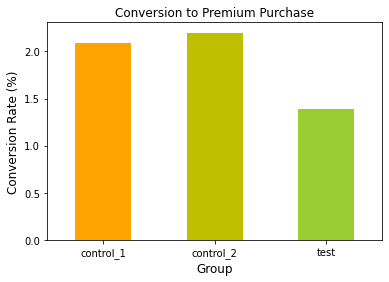

In [31]:
# Визуализируем конверсию
conversion.plot(kind="bar", color=["orange", "y", "yellowgreen"], legend=False)
plt.title("Conversion to Premium Purchase")
plt.xlabel("Group", fontsize=12)
plt.ylabel("Conversion Rate (%)", fontsize=12)
plt.xticks(rotation="horizontal")

In [32]:
# Посмотрим стат. значимость полученных результатов
# Т.к. метрика бинарная (условно категориальная, принимает только 2 значения),
# то используем непараметрический тест ХИ квадрат

In [33]:
alpha = 0.05
bonferroni_alpha = alpha / 3
# делаем поправку на множественные сравнения (3 попарных, значит порог значимости делим на 3 )

In [34]:
print("Test и Control_1")
subset = users[users["group"].isin(["test", "control_1"])]
table = pd.crosstab(subset["group"], subset["premium_buyer"])
chi2, p, dof, expected = st.chi2_contingency(table)

if p < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")

Test и Control_1
Не значимо


In [35]:
print("Test и Control_2")
subset = users[users["group"].isin(["test", "control_2"])]
table = pd.crosstab(subset["group"], subset["premium_buyer"])
chi2, p, dof, expected = st.chi2_contingency(table)

if p < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")

Test и Control_2
ЗНАЧИМО


In [36]:
print("Control_1 и Control_2")
subset = users[users["group"].isin(["control_1", "control_2"])]
table = pd.crosstab(subset["group"], subset["premium_buyer"])
chi2, p, dof, expected = st.chi2_contingency(table)

if p < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")

Control_1 и Control_2
Не значимо


In [37]:
# Посмотрим на retention премиума

In [38]:
# Отфильтруем только премиум-транзакции
premium_transactions = transactions[transactions["product_type"] == "premium_no_trial"]

In [39]:
counts = (
    premium_transactions.groupby(["group", "uid"]).size().reset_index(name="payments")
)
counts["retained"] = counts["payments"] > 1

In [40]:
print("Распределение количества платежей на пользователя:")
print(premium_transactions.groupby("uid").size().value_counts().sort_index())
# Здесь становится понятно, что пользователи почти не продлевают премиум.

Распределение количества платежей на пользователя:
1    226
2      9
3      2
dtype: int64


In [41]:
# Посчитаем и визуализируем retention для каждой группы
retention_stats = counts.groupby("group")["retained"].agg(
    retained_users="sum", total_users="count"
)
retention_stats["retention_rate"] = (
    retention_stats["retained_users"] / retention_stats["total_users"] * 100
)

print("Retention по группам:")
print(retention_stats)

Retention по группам:
           retained_users  total_users  retention_rate
group                                                 
control_1               6           88        6.818182
control_2               3           91        3.296703
test                    2           58        3.448276


(array([0, 1, 2]), <a list of 3 Text major ticklabel objects>)

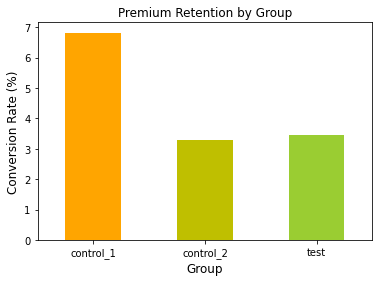

In [42]:
retention_stats["retention_rate"].plot(
    kind="bar", color=["orange", "y", "yellowgreen"], legend=False
)

plt.title("Premium Retention by Group")
plt.xlabel("Group", fontsize=12)
plt.ylabel("Conversion Rate (%)", fontsize=12)
plt.xticks(rotation="horizontal")

In [43]:
# Теперь проверим статистическую значимость полученных результатов

print("Test vs Control_1:")
test_row = retention_stats.loc["test", ["retained_users", "total_users"]].values
control1_row = retention_stats.loc[
    "control_1", ["retained_users", "total_users"]
].values

table = [
    [int(test_row[0]), int(test_row[1] - test_row[0])],
    [int(control1_row[0]), int(control1_row[1] - control1_row[0])],
]

stat, pval = st.fisher_exact(table)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print(" Не значимо")
print()

Test vs Control_1:
 Не значимо



In [44]:
print("Test vs Control_2:")
control2_row = retention_stats.loc[
    "control_2", ["retained_users", "total_users"]
].values

table = [
    [int(test_row[0]), int(test_row[1] - test_row[0])],
    [int(control2_row[0]), int(control2_row[1] - control2_row[0])],
]

stat, pval = st.fisher_exact(table)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print(" Не значимо")
print()

Test vs Control_2:
 Не значимо



In [45]:
print("Control_1 vs Control_2:")
table = [
    [int(control1_row[0]), int(control1_row[1] - control1_row[0])],
    [int(control2_row[0]), int(control2_row[1] - control2_row[0])],
]

stat, pval = st.fisher_exact(table)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print(" Не значимо")
print()

Control_1 vs Control_2:
 Не значимо



### АНАЛИЗ ВЫРУЧКИ

In [46]:
# проведем агрегацию выручки на уровне пользователей

user_revenue = transactions.groupby(["uid", "group"], as_index=False)["revenue"].sum()
user_revenue_full = users[["uid", "group", "country"]].merge(
    user_revenue, on=["uid", "group"], how="left"
)
user_revenue_full["revenue"] = user_revenue_full["revenue"].fillna(0)

In [47]:
# Выручка по группам - полная статистика
# Выручка по группам - статистика на уровне пользователей
print("Выручка по группам (user level)")
print()
revenue_stats = (
    user_revenue_full.groupby("group")
    .agg({"revenue": ["count", "mean", "median", "std", "min", "max", "sum"]})
    .round(2)
)

print(revenue_stats)
print()

# Выручка на одного пользователя (ARPU)

print()
print("ARPU — выручка на одного пользователя")
print()

arpu = user_revenue_full.groupby("group")["revenue"].mean()

print(arpu.round(2))
print()


print()
print("ARPPU — выручка на одного премиум покупателя")
print()

premium_transactions = transactions[transactions["product_type"] == "premium_no_trial"]

premium_user_revenue = premium_transactions.groupby(["uid", "group"], as_index=False)[
    "revenue"
].sum()

arppu = (
    premium_user_revenue.groupby("group")
    .agg({"revenue": ["mean", "sum", "count"]})
    .round(2)
)

print(arppu)
print()

Выручка по группам (user level)

          revenue                                                  
            count    mean median      std  min       max        sum
group                                                              
control_1    4215  541.69    0.0  8006.73  0.0  486330.0  2283203.0
control_2    4142  353.92    0.0  2567.42  0.0   81796.0  1465932.0
test         4166  457.16    0.0  4173.62  0.0  129870.0  1904513.0


ARPU — выручка на одного пользователя

group
control_1    541.69
control_2    353.92
test         457.16
Name: revenue, dtype: float64


ARPPU — выручка на одного премиум покупателя

            revenue                
               mean       sum count
group                              
control_1   8077.43  710814.0    88
control_2   7450.00  677950.0    91
test       11999.00  695942.0    58



Text(0.5, 0, 'Amount')

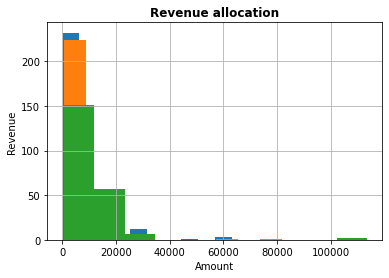

In [48]:
# Распределение выручки в группах
transactions.groupby("group")["revenue"].hist()
plt.title("Revenue allocation", fontweight="bold")
plt.ylabel("Revenue")
plt.xlabel("Amount")
# Ассиметрично, с выбросами

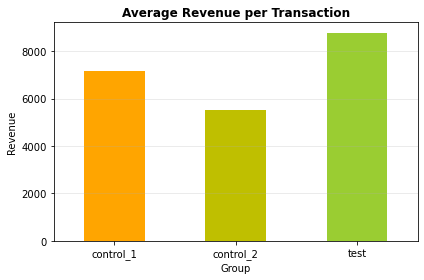

In [49]:
# Средняя выручка на транзакцию
mean_rev = transactions.groupby("group")["revenue"].mean()
mean_rev.plot(kind="bar", color=["orange", "y", "yellowgreen"], legend=False)
plt.title("Average Revenue per Transaction", fontweight="bold")
plt.ylabel("Revenue")
plt.xlabel("Group")
plt.xticks(rotation="horizontal")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

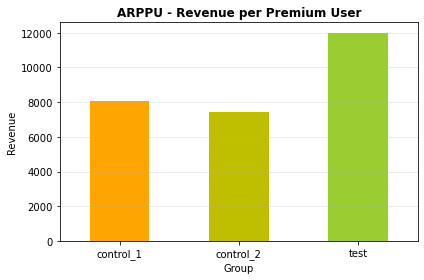

In [50]:
# ARPPU

arppu.iloc[:, 0].plot(kind="bar", color=["orange", "y", "yellowgreen"], legend=False)

plt.title("ARPPU - Revenue per Premium User", fontweight="bold")
plt.ylabel("Revenue")
plt.xlabel("Group")
plt.xticks(rotation="horizontal")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

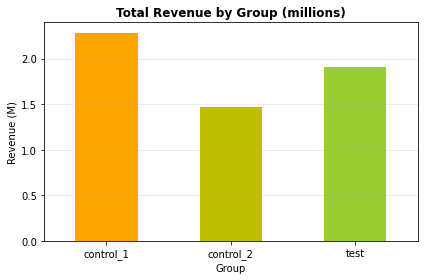

In [51]:
# Общая выручка на группу
total_rev = user_revenue_full.groupby("group")["revenue"].sum() / 1000000
total_rev.plot(kind="bar", color=["orange", "y", "yellowgreen"], legend=False)
plt.title("Total Revenue by Group (millions)", fontweight="bold")
plt.ylabel("Revenue (M)")
plt.xlabel("Group")
plt.xticks(rotation="horizontal")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

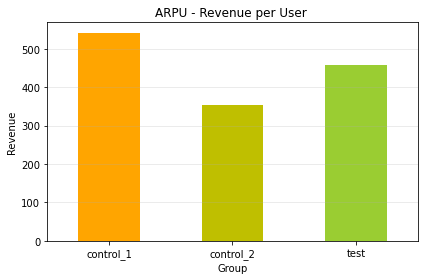

In [52]:
# ARPU (на одного пользователя)
arpu.plot(kind="bar", color=["orange", "y", "yellowgreen"], legend=False)
plt.title("ARPU - Revenue per User ")
plt.ylabel("Revenue")
plt.xlabel("Group")
plt.xticks(rotation="horizontal")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [53]:
print("Количество набюдений в каждой группе (Revenue)")
print("test_rev: ", user_revenue[user_revenue["group"] == "test"]["revenue"].count())
print(
    "control1_rev: ",
    user_revenue[user_revenue["group"] == "control_1"]["revenue"].count(),
)
print(
    "control2_rev: ",
    user_revenue[user_revenue["group"] == "control_2"]["revenue"].count(),
)
print()
print("Проверка гомогенности диспресий")
print(pg.homoscedasticity(data=user_revenue, dv="revenue", group="group"))
print("Проверка нормальности распределений")
print(pg.normality(data=user_revenue, dv="revenue", group="group"))

Количество набюдений в каждой группе (Revenue)
test_rev:  126
control1_rev:  167
control2_rev:  151

Проверка гомогенности диспресий
               W      pval  equal_var
levene  0.980306  0.376012       True
Проверка нормальности распределений
                  W          pval  normal
group                                    
control_2  0.546014  1.036343e-19   False
test       0.514312  1.289237e-18   False
control_1  0.172584  1.171664e-26   False


In [54]:
test_rev = user_revenue[user_revenue["group"] == "test"]["revenue"]
control1_rev = user_revenue[user_revenue["group"] == "control_1"]["revenue"]
control2_rev = user_revenue[user_revenue["group"] == "control_2"]["revenue"]

In [55]:
print("Статистические тесты выручки")
print()
print("95% доверительные интервалы разницы средних:")
ci = pg.compute_bootci(
    test_rev, control1_rev, func=lambda x, y: x.mean() - y.mean(), n_boot=10000
)
print("Test vs Control 1:")
print(ci)
ci = pg.compute_bootci(
    test_rev, control2_rev, func=lambda x, y: x.mean() - y.mean(), n_boot=10000
)
print("Test vs Control 2:")
print(ci)
ci = pg.compute_bootci(
    control1_rev, control2_rev, func=lambda x, y: x.mean() - y.mean(), n_boot=10000
)
print("Control 1 vs Control 2:")
print(ci)

Статистические тесты выручки

95% доверительные интервалы разницы средних:
Test vs Control 1:
[-6908.19  6655.05]
Test vs Control 2:
[2135.01 9437.73]
Control 1 vs Control 2:
[ -143.94 11936.91]


Значимый результат (0 не попадает в интервал) только в случае тестовой группы и второй контрольной. Разброс в интервалах большой, что свидетельствует о высокой изменчивости и/или выбросах. 

Для проверки выручки и ARPPU будм использовать бутстрап, так как распределения сильно ненормальные, очевидно скошены влево, имеют выбросы, небольшое количество наблюдений (примерно 130) и сравниваем именно средние значения. 

В случае с ARPU - это будет Т-тест, так как число набюдений большое > 4000, а сам Т-тест работает с ЦПТ, что позволяет ему быть устойчивым в таком случае. 

In [56]:
print("Количество набюдений в каждой группе (ARPU)")
print(
    "test_arpu: ",
    user_revenue_full[user_revenue_full["group"] == "test"]["revenue"].count(),
)
print(
    "control1_arpu: ",
    user_revenue_full[user_revenue_full["group"] == "control_1"]["revenue"].count(),
)
print(
    "control2_arpu: ",
    user_revenue_full[user_revenue_full["group"] == "control_2"]["revenue"].count(),
)
print()
print("Проверка гомогенности диспресий")
print(pg.homoscedasticity(data=user_revenue_full, dv="revenue", group="group"))
print("Проверка нормальности распределений")
print(pg.normality(data=user_revenue_full, dv="revenue", group="group"))

Количество набюдений в каждой группе (ARPU)
test_arpu:  4166
control1_arpu:  4215
control2_arpu:  4142

Проверка гомогенности диспресий
               W      pval  equal_var
levene  1.249572  0.286663       True
Проверка нормальности распределений
                  W          pval  normal
group                                    
test       0.083628  5.223578e-89   False
control_1  0.033964  1.626262e-90   False
control_2  0.118116  5.426706e-88   False


In [57]:
# ТАк как наблюдений в группе достаточно, 
# а т-тест робастен к ненормальному распределению при большом количестве наблюдений
# (так как работает через ЦПТ), то можно использовать именно его. Стоит упомянуть и гомогенность дисперсий, это важно.
print("Статистические тесты ARPU")
print()

alpha = 0.05
bonferroni_alpha = alpha / 3

# разделяем группы
test_arpu = user_revenue_full[user_revenue_full["group"] == "test"]["revenue"]
control1_arpu = user_revenue_full[user_revenue_full["group"] == "control_1"]["revenue"]
control2_arpu = user_revenue_full[user_revenue_full["group"] == "control_2"]["revenue"]


# Test vs Control_1
print("Test vs Control_1:")
stat, pval = st.ttest_ind(test_arpu, control1_arpu, equal_var=False)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")
print()


# Test vs Control_2
print("Test vs Control_2:")
stat, pval = st.ttest_ind(test_arpu, control2_arpu, equal_var=False)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")
print()


# Control_1 vs Control_2
print("Control_1 vs Control_2:")
stat, pval = st.ttest_ind(control1_arpu, control2_arpu, equal_var=False)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")
print()

print("Дополнительная проверка попарными сравнениями из другой библиотеки")
print(
    pg.pairwise_tests(
        data=user_revenue_full, dv="revenue", between="group", padjust="fdr_bh"
    )
)
print()
print("Вывод: различия между метрикой ARPU между группами не является значимым")

Статистические тесты ARPU

Test vs Control_1:
Не значимо

Test vs Control_2:
Не значимо

Control_1 vs Control_2:
Не значимо

Дополнительная проверка попарными сравнениями из другой библиотеки
  Contrast          A          B  Paired  Parametric         T          dof  \
0    group  control_1  control_2   False        True  1.448612  5085.327872   
1    group  control_1       test   False        True  0.607028  6362.895668   
2    group  control_2       test   False        True -1.358778  6929.205144   

  alternative     p-unc    p-corr p-adjust   BF10    hedges  
0   two-sided  0.147508  0.261392   fdr_bh   0.07  0.031466  
1   two-sided  0.543854  0.543854   fdr_bh   0.03  0.013216  
2   two-sided  0.174261  0.261392   fdr_bh  0.062 -0.029773  

Вывод: различия между метрикой ARPU между группами не является значимым


In [58]:
print("Количество набюдений в каждой группе (ARPPU)")
print(
    "test_arppu: ",
    premium_user_revenue[premium_user_revenue["group"] == "test"]["revenue"].count(),
)
print(
    "control1_arppu: ",
    premium_user_revenue[premium_user_revenue["group"] == "control_1"][
        "revenue"
    ].count(),
)
print(
    "control2_arppu: ",
    premium_user_revenue[premium_user_revenue["group"] == "control_2"][
        "revenue"
    ].count(),
)
print()
print("Проверка гомогенности диспресий")
print(pg.homoscedasticity(data=premium_user_revenue, dv="revenue", group="group"))
print("Проверка нормальности распределений")
print(pg.normality(data=premium_user_revenue, dv="revenue", group="group"))

Количество набюдений в каждой группе (ARPPU)
test_arppu:  58
control1_arppu:  88
control2_arppu:  91

Проверка гомогенности диспресий
               W     pval  equal_var
levene  1.429884  0.24142       True
Проверка нормальности распределений
                  W          pval  normal
group                                    
control_2  0.269673  3.541172e-19   False
test       0.322363  6.805177e-15   False
control_1  0.352521  7.269447e-18   False


In [59]:
test_arppu = premium_user_revenue[premium_user_revenue["group"] == "test"]["revenue"]
control1_arppu = premium_user_revenue[premium_user_revenue["group"] == "control_1"][
    "revenue"
]
control2_arppu = premium_user_revenue[premium_user_revenue["group"] == "control_2"][
    "revenue"
]

In [60]:
print("Статистические тесты ARPPU")
print()
print("95% доверительные интервалы разницы средних:")
ci = pg.compute_bootci(
    test_arppu, control1_arppu, func=lambda x, y: x.mean() - y.mean(), n_boot=10000
)
print("Test vs Control 1:")
print(ci)
ci = pg.compute_bootci(
    test_arppu, control2_arppu, func=lambda x, y: x.mean() - y.mean(), n_boot=10000
)
print("Test vs Control 2:")
print(ci)
ci = pg.compute_bootci(
    control1_arppu, control2_arppu, func=lambda x, y: x.mean() - y.mean(), n_boot=10000
)
print("Control 1 vs Control 2:")
print(ci)

Статистические тесты ARPPU

95% доверительные интервалы разницы средних:
Test vs Control 1:
[ -705.03 10686.5 ]
Test vs Control 2:
[  188.88 11201.3 ]
Control 1 vs Control 2:
[-2518.06  3772.83]


Значимые различия присутствуют только между тестовой группой и вторым контролем, так как интервал не проходит через 0. Более того, так как этот интервал полность положителен, то тест > контроля 2

## Срез по странам
### Конверсия и ARPU


In [61]:
# Проверим соответствие распределение групп по странам статистически

table = pd.crosstab(users["group"], users["country"])
chi2, p, dof, expected = st.chi2_contingency(table)

print("p-value:", p)
# p-value: 0.989 - различия статистически не значимы

p-value: 0.9893488932278771


In [62]:
# Посчитаем обе метрики, которые будут ненулевыми в каждой группе
print("Конверсияя по странам (%)")
conversion_country = (
    pd.pivot_table(
        users, values="premium_buyer", index="country", columns="group", aggfunc="mean") * 100)
print(conversion_country.round(3))

Конверсияя по странам (%)
group                           control_1  control_2    test
country                                                     
Argentina                           1.055      1.818   1.295
Australia                           2.000      1.961   0.000
Belgium                             0.000      5.618   1.111
Canada                              3.077      0.763   2.239
Chile                               1.429      1.434   0.746
Colombia                            0.000      0.000   0.000
Costa Rica                          0.000      0.000   0.000
Dominican Republic                  0.000      0.000   0.000
France                              2.997      2.174   0.857
Germany                             2.174      0.995   0.976
India                              33.333      0.000   0.000
Israel                              8.654      2.597   1.905
Italy                               2.736      1.394   1.911
Kyrgyzstan                          0.000      0.000   0.00

In [63]:
print("ARPU по странам")
arpu_country = pd.pivot_table(
    user_revenue_full,
    values="revenue",
    index="country",
    columns="group",
    aggfunc="mean",
)

print(arpu_country.round(3))

ARPU по странам
group                           control_1  control_2      test
country                                                       
Argentina                         264.596    281.577   487.096
Australia                         366.080    185.059     0.000
Belgium                           401.774   1051.685   326.011
Canada                            577.900    135.160   420.560
Chile                             313.021    296.624    94.056
Colombia                            0.000      0.000     0.000
Costa Rica                          0.000      0.000     0.000
Dominican Republic                  0.000      0.000     0.000
France                            428.256    233.541   510.640
Germany                           130.424    134.075   468.761
India                            1603.333      0.000     0.000
Israel                           1061.125    524.896   902.943
Italy                            1802.219    349.098   252.838
Kyrgyzstan                          0.0

In [64]:
# Сравниваем конверсию в премиум статистически.
# Берем z тест пропорций, так как у нас бинарные доли и приемлимого размера выборки
# Для каждой такой страны считаем количество премиум пользователей и всех пользователей в общем
# Дальше мы сравниваем доли.

results = []
# Берем только страны, где есть все 3 группы
valid_countries = users.groupby("country")["group"].nunique()
valid_countries = valid_countries[valid_countries == 3].index

for country in valid_countries:

    data = users[users["country"] == country]
    test = data[data["group"] == "test"]["premium_buyer"]
    control = data[data["group"] == "control_1"]["premium_buyer"]

    successes = [test.sum(), control.sum()]
    nobs = [len(test), len(control)]

    stat, pval = proportions_ztest(successes, nobs)

    results.append(
        {
            "country": country,
            "test_conv": test.mean() * 100,
            "control_conv": control.mean() * 100,
            "p_value": pval,
        }
    )

results_df = pd.DataFrame(results).dropna()
results_df = results_df.sort_values("p_value")

print(results_df.head(10))

                     country  test_conv  control_conv   p_value
11                    Israel   1.904762      8.653846  0.028908
8                     France   0.857143      2.997275  0.038428
24  United States of America   1.203966      1.820728  0.178370
10                     India   0.000000     33.333333  0.196706
1                  Australia   0.000000      2.000000  0.267195
2                    Belgium   1.111111      0.000000  0.276580
22      United Arab Emirates   2.314815      0.975610  0.282780
16                  Portugal   0.000000      1.010101  0.336412
9                    Germany   0.975610      2.173913  0.338300
19               Switzerland   0.000000      2.439024  0.352332


/opt/conda/lib/python3.9/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


In [65]:
# снова применяем поправку на множественное сравнение, тут уже делим на количество стран, т.к.
# количество стран и есть число независимых тестов, которые мы проводим
alpha = 0.05
bonferroni_alpha = alpha / len(results_df)
results_df["significant"] = results_df["p_value"] < bonferroni_alpha

In [66]:
significant_countries = results_df[results_df["significant"]]
print(significant_countries)

Empty DataFrame
Columns: [country, test_conv, control_conv, p_value, significant]
Index: []


In [67]:
# Повторяем с другой группой
results = []

valid_countries = users.groupby("country")["group"].nunique()
valid_countries = valid_countries[valid_countries == 3].index

for country in valid_countries:

    data = users[users["country"] == country]

    test = data[data["group"] == "test"]["premium_buyer"]
    control = data[data["group"] == "control_2"]["premium_buyer"]
    successes = [test.sum(), control.sum()]
    nobs = [len(test), len(control)]

    stat, pval = proportions_ztest(successes, nobs)

    results.append(
        {
            "country": country,
            "test_conv": test.mean() * 100,
            "control_conv": control.mean() * 100,
            "p_value": pval,
        }
    )

results_df = pd.DataFrame(results).dropna()
results_df = results_df.sort_values("p_value")

print(results_df.head(20))

                           country  test_conv  control_conv   p_value
16                        Portugal   0.000000      5.050505  0.029811
24        United States of America   1.203966      2.002762  0.089550
2                          Belgium   1.111111      5.617978  0.093931
19                     Switzerland   0.000000      5.882353  0.145360
8                           France   0.857143      2.173913  0.151031
20                          Turkey  25.000000      0.000000  0.235680
1                        Australia   0.000000      1.960784  0.271956
18                           Spain   1.700680      2.970297  0.305438
3                           Canada   2.238806      0.763359  0.324682
21                         Ukraine   0.000000      6.666667  0.325513
23  United Kingdom (Great Britain)   3.030303      4.827586  0.413065
14                          Mexico  14.285714      0.000000  0.427880
4                            Chile   0.746269      1.433692  0.440329
0                   

/opt/conda/lib/python3.9/site-packages/statsmodels/stats/weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


In [68]:
bonferroni_alpha = alpha / len(results_df)
results_df["significant"] = results_df["p_value"] < bonferroni_alpha

In [69]:
significant_countries = results_df[results_df["significant"]]
print(significant_countries)
# Результаты обоих тестов не значимы

Empty DataFrame
Columns: [country, test_conv, control_conv, p_value, significant]
Index: []


### Сравниваем метрики после удаления выбросов

In [70]:
print("Анализ выбросов для ARPU")
# 98 перцентиль
q98 = user_revenue_full["revenue"].quantile(0.98)

print(f"98-й перцентиль: {q98:.2f}")

# доля выбросов
trasher = user_revenue_full[user_revenue_full["revenue"] > q98]
print("Количество выбросов: ", len(trasher))
print("Доля выбросов: ", round(len(trasher) / len(user_revenue_full) * 100, 2), "%")

# удаляем выбросы
filtered_revenue = user_revenue_full[user_revenue_full["revenue"] <= q98]

Анализ выбросов для ARPU
98-й перцентиль: 8576.88
Количество выбросов:  251
Доля выбросов:  2.0 %


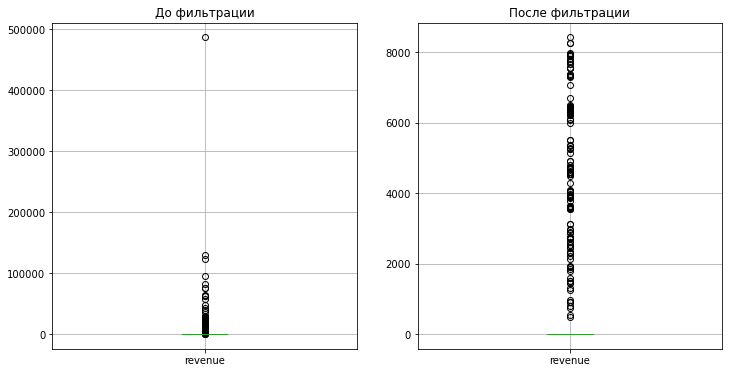

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
user_revenue_full.boxplot(column="revenue", ax=axes[0])
axes[0].set_title("До фильтрации")

filtered_revenue.boxplot(column="revenue", ax=axes[1])
axes[1].set_title("После фильтрации")

plt.show()

Когда quantile(0.95) равен 0, это факт: как минимум 95% пользователей не принесли никакой выручки (их revenue равен 0), поэтому тут возьмем 98-й перцентиль, чтобы убрать основной очевидных выброс в данных. Для выручки в приложениях, где можно не оформлять подписку - это нормально. Платящих всегда меньше.


In [72]:
print("Тесты без выбросов (ARPU)")
print()
test_clean = filtered_revenue[filtered_revenue["group"] == "test"]["revenue"]
control1_clean = filtered_revenue[filtered_revenue["group"] == "control_1"]["revenue"]
control2_clean = filtered_revenue[filtered_revenue["group"] == "control_2"]["revenue"]

bonferroni_alpha = 0.05 / 3

# Test vs Control_1
print("Test vs Control_1:")
stat, pval = st.ttest_ind(test_clean, control1_clean, equal_var=False)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")
print()

# Test vs Control_2
print("Test vs Control_2:")
stat, pval = st.ttest_ind(test_clean, control2_clean, equal_var=False)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")
print()

# Control_1 vs Control_2
print("Control_1 vs Control_2:")
stat, pval = st.ttest_ind(control1_clean, control2_clean, equal_var=False)
if pval < bonferroni_alpha:
    print("ЗНАЧИМО")
else:
    print("Не значимо")
print()

Тесты без выбросов (ARPU)

Test vs Control_1:
ЗНАЧИМО

Test vs Control_2:
ЗНАЧИМО

Control_1 vs Control_2:
Не значимо



Вывод: После очистки данных результаты стали значимы между тестовой группой и контрольными.

In [73]:
print("Анализ выбросов для ARPPU")
# 95 перцентиль так как очевидных выбросов здесь больше (см график ниже)
q95 = premium_user_revenue["revenue"].quantile(0.95)

print(f"95-й перцентиль: {q95:.2f}")

# доля выбросов
trasher = premium_user_revenue[premium_user_revenue["revenue"] > q95]
print("Количество выбросов: ", len(trasher))
print("Доля выбросов: ", round(len(trasher) / len(premium_user_revenue) * 100, 2), "%")

# удаляем выбросы
filtered_premium_revenue = premium_user_revenue[premium_user_revenue["revenue"] <= q95]

Анализ выбросов для ARPPU
95-й перцентиль: 12597.00
Количество выбросов:  11
Доля выбросов:  4.64 %


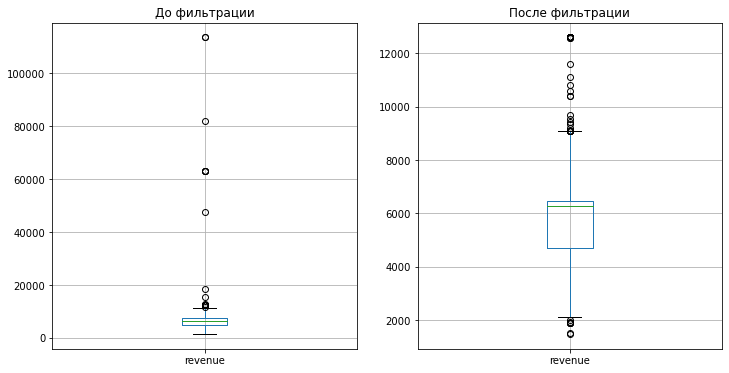

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
premium_user_revenue.boxplot(column="revenue", ax=axes[0])
axes[0].set_title("До фильтрации")

filtered_premium_revenue.boxplot(column="revenue", ax=axes[1])
axes[1].set_title("После фильтрации")

plt.show()

In [75]:
test_arppu_clean = filtered_premium_revenue[
    filtered_premium_revenue["group"] == "test"
]["revenue"]
control1_arppu_clean = filtered_premium_revenue[
    filtered_premium_revenue["group"] == "control_1"
]["revenue"]
control2_arppu_clean = filtered_premium_revenue[
    filtered_premium_revenue["group"] == "control_2"
]["revenue"]

In [76]:
print("Статистические тесты ARPPU")
print()
print("95% доверительные интервалы разницы средних:")
print()

ci = pg.compute_bootci(
    test_arppu_clean,
    control1_arppu_clean,
    func=lambda x, y: x.mean() - y.mean(),
    n_boot=10000,
)
print("Test vs Control 1:")
print(ci)
print()

ci = pg.compute_bootci(
    test_arppu_clean,
    control2_arppu_clean,
    func=lambda x, y: x.mean() - y.mean(),
    n_boot=10000,
)
print("Test vs Control 2:")
print(ci)
print()

ci = pg.compute_bootci(
    control1_arppu_clean,
    control2_arppu_clean,
    func=lambda x, y: x.mean() - y.mean(),
    n_boot=10000,
)
print("Control 1 vs Control 2:")
print(ci)

Статистические тесты ARPPU

95% доверительные интервалы разницы средних:

Test vs Control 1:
[1724.76 3574.06]

Test vs Control 2:
[1405.33 3216.37]

Control 1 vs Control 2:
[-869.81  228.69]


первичные выводы по ARPPU оказались почти не значимыми из-за влияния выбросов. После удаления 5% экстремальных значений эффект приобретает значимость.

In [77]:
print("Анализ выбросов для Revenue")
# 95 перцентиль
q95 = user_revenue["revenue"].quantile(0.95)

print(f"95-й перцентиль: {q95:.2f}")

# доля выбросов
trasher = user_revenue[user_revenue["revenue"] > q95]
print("Количество выбросов: ", len(trasher))
print("Доля выбросов: ", round(len(trasher) / len(user_revenue) * 100, 2), "%")

# удаляем выбросы
filtered_user_revenue = user_revenue[user_revenue["revenue"] <= q95]

Анализ выбросов для Revenue
95-й перцентиль: 25573.60
Количество выбросов:  23
Доля выбросов:  5.18 %


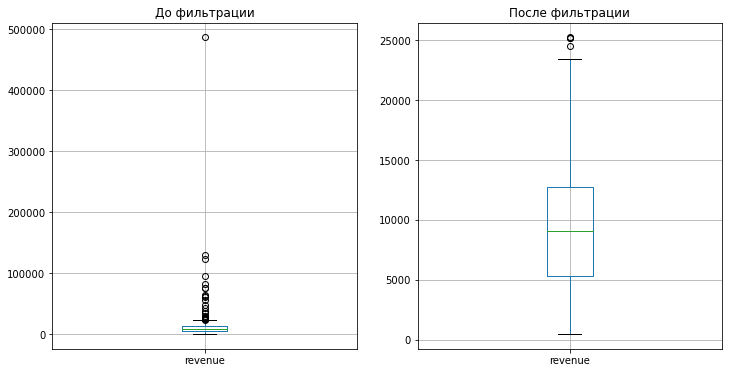

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
user_revenue.boxplot(column="revenue", ax=axes[0])
axes[0].set_title("До фильтрации")

filtered_user_revenue.boxplot(column="revenue", ax=axes[1])
axes[1].set_title("После фильтрации")

plt.show()

In [79]:
test_rev_clean = filtered_user_revenue[filtered_user_revenue["group"] == "test"][
    "revenue"
]
control1_rev_clean = filtered_user_revenue[
    filtered_user_revenue["group"] == "control_1"
]["revenue"]
control2_rev_clean = filtered_user_revenue[
    filtered_user_revenue["group"] == "control_2"
]["revenue"]

In [80]:
print("Статистические тесты Revenue")
print()
print("95% доверительные интервалы разницы средних:")
print()

ci = pg.compute_bootci(
    test_rev_clean,
    control1_rev_clean,
    func=lambda x, y: x.mean() - y.mean(),
    n_boot=10000,
)
print("Test vs Control 1:")
print(ci)
print()

ci = pg.compute_bootci(
    test_rev_clean,
    control2_rev_clean,
    func=lambda x, y: x.mean() - y.mean(),
    n_boot=10000,
)
print("Test vs Control 2:")
print(ci)
print()

ci = pg.compute_bootci(
    control1_rev_clean,
    control2_rev_clean,
    func=lambda x, y: x.mean() - y.mean(),
    n_boot=10000,
)
print("Control 1 vs Control 2:")
print(ci)

Статистические тесты Revenue

95% доверительные интервалы разницы средних:

Test vs Control 1:
[ 342.4  2920.29]

Test vs Control 2:
[ 747.62 3350.53]

Control 1 vs Control 2:
[-682.15 1545.66]


Вывод: после чистки данных, выручка в тестовой и контрольных группах значимо различается (test > control) 

In [81]:
print("ARPU-clean по странам")
arpu_country = pd.pivot_table(
    filtered_revenue,
    values="revenue",
    index="country",
    columns="group",
    aggfunc="mean",
)

print(arpu_country.round(3))

ARPU-clean по странам
group                           control_1  control_2     test
country                                                      
Argentina                          20.358     44.420   30.504
Australia                         100.020      0.000    0.000
Belgium                             0.000    383.729   44.466
Canada                            115.452     60.700   53.300
Chile                              66.891     33.810   30.966
Colombia                            0.000      0.000    0.000
Costa Rica                          0.000      0.000    0.000
Dominican Republic                  0.000      0.000    0.000
France                            144.625    157.101   36.560
Germany                           130.424     71.110   59.373
India                            1603.333      0.000    0.000
Israel                            529.100    202.800    0.000
Italy                              75.255    133.365   12.411
Kyrgyzstan                          0.000      0

In [82]:
counts_country_group = (filtered_revenue.groupby(["country", "group"]).size().unstack(fill_value=0))

print("Количество записей по странам и группам:")
print(counts_country_group)

Количество записей по странам и группам:
group                           control_1  control_2  test
country                                                   
Argentina                             371        379   381
Australia                              49         50    61
Belgium                               103         85    88
Canada                                126        130   130
Chile                                 275        273   267
Colombia                                1          2     1
Costa Rica                              1          1     1
Dominican Republic                      2          1     1
France                                360        366   341
Germany                               184        200   201
India                                   6          2     4
Israel                                100         75   100
Italy                                 322        282   309
Kyrgyzstan                              1          1     1
Mexico         

In [83]:
def bootstrap_mean_diff(data1, data2, n_bootstrap=10000, seed=42):
    np.random.seed(seed)
    boot_diffs = []
    for i in range(n_bootstrap):
        sample1 = np.random.choice(data1, size=len(data1), replace=True)
        sample2 = np.random.choice(data2, size=len(data2), replace=True)
        boot_diffs.append(np.mean(sample1) - np.mean(sample2))
    lower = np.percentile(boot_diffs, 2.5)
    upper = np.percentile(boot_diffs, 97.5)
    mean_diff = np.mean(data1) - np.mean(data2)
    return mean_diff, (lower, upper)


groups = filtered_revenue["group"].unique()
results = []

for country in filtered_revenue["country"].unique():
    data_country = filtered_revenue[filtered_revenue["country"] == country]

    for g1, g2 in combinations(groups, 2):
        data1 = data_country[data_country["group"] == g1]["revenue"].values
        data2 = data_country[data_country["group"] == g2]["revenue"].values

        # нужно хотя бы 2 наблюдений в каждой группе
        if len(data1) > 1 and len(data2) > 1:
            mean_diff, ci = bootstrap_mean_diff(data1, data2)
            significant = not (ci[0] <= 0 <= ci[1])
            results.append([country, g1, g2, mean_diff, ci[0], ci[1], significant])
        else:
            results.append([country, g1, g2, None, None, None, False])

bootstrap_df = pd.DataFrame(
    results,
    columns=[
        "country",
        "group1",
        "group2",
        "mean_diff",
        "CI_lower",
        "CI_upper",
        "significant",
    ],
)

print(bootstrap_df)
print(bootstrap_df[bootstrap_df["significant"]])

                     country     group1     group2  mean_diff    CI_lower  \
0   United States of America       test  control_1 -28.416644  -65.166449   
1   United States of America       test  control_2 -66.891139 -110.998959   
2   United States of America  control_1  control_2 -38.474495  -87.173988   
3                    Germany       test  control_1 -71.050779 -224.254244   
4                    Germany       test  control_2 -11.736866 -144.608556   
..                       ...        ...        ...        ...         ...   
70        Dominican Republic       test  control_2        NaN         NaN   
71        Dominican Republic  control_1  control_2        NaN         NaN   
72                Costa Rica       test  control_1        NaN         NaN   
73                Costa Rica       test  control_2        NaN         NaN   
74                Costa Rica  control_1  control_2        NaN         NaN   

      CI_upper  significant  
0     7.110422        False  
1   -24.451937 

В развитых странах (Бельгия, Италия, Франция, Португалия) наблюдается значимое различие, но отрицательное, т.е. в тестовой группе ARPU меньше, чем в контрольных.

### Почему мы не используем критерий Манна-Уитни для сравнения средних. 

 - Критерий Манна-Уитни сравнивает, насколько ранги (места) значений в одной независимой выборке выше или ниже рангов в другой, оценивая **вероятность того, что случайное значение из одной группы больше случайного из другой.** Он не подходит для сравнения средних, так как работает с рангами, а не самими значениями, и проверяет различия в распределениях, а не конкретно в средних арифметических.
 
 - Он проверяет гипотезу о том, что распределение значений в двух выборках одинаково, против альтернативы, что одна выборка имеет тенденцию принимать большие значения, чем другая.

# Отчет по результатам A/B-тестирования 

## Цель эксперимента

В рамках эксперимента была изменена цена премиум-подписки для новых пользователей приложения.

Изменения применялись только при выполнении следующих условий:

- пользователь является новым
- оплата производится через две новые платежные системы
- цена пробного периода (trial) не изменялась

Цель эксперимента — оценить влияние изменения цены на ключевые бизнес-метрики:
- конверси в премиум подписку
- выручку
- ARPU
- ARPPU 


# Общие результаты эксперимента

## Конверсия в покупку премиум-подписки

- Тестовая группа конвертируется ниже, чем контрольные группы. (1.4, 2.18, 2.08)
- Разница между двумя контрольными группами почти отсутствует, значит можно считать, что контроль правильный, группы не влияют на разницу в конверсии сами по себе.
- Статистическая проверка подтвердила значимое снижение конверсии в тестовой группе относительно control_2 . Это ожидаемый эффект при повышении стоимости подписки, хоть и наблюдается не во всех контрольных.

#### Что это для нас значит? 

Эксперимент **не принес улучшения**, в одном случает конверсия все-таки значимо понизилась в тестовой группе. 



# Выручка

Для сравнения выручки между группами использовался **бутстрап доверительных интервалов** разницы средних, так как распределение доходов имеет сильную асимметрию, выбросы и небольшое количество наблюдений.

Первичный анализ показал статистически значимое превосходство тестовой группы над контрольной второй.

Однако дальнейший анализ с удалением выбросов показал, что различие между тестовыми и контрольными группами является статистически значимым! 

### Вывод

Наблюдаемый рост выручки в тестовой группе не обуславливается выбросами или экстремальными значениями, оно **значимо** и перекрывает падение конверсии (меньше лдей, но платят больше).


# ARPU (Average Revenue Per User)

ARPU рассчитывался как средний доход на пользователя.

Для проверки различий использовался **t-тест** (большие выборки, ЦПТ) и дополнительно анализ без выбросов.

После удаления 2% выбросов (98-й перцентиль) различия между тестовой группой и обеими контрольными стали статистически **значимыми**!


### Вывод

Изменение цены подписки привело к **статистически значимому росту ARPU**. Тестовая стратегия оказалась эффективнее текущей.



# ARPPU (Average Revenue Per Paying User)

ARPPU показывает средний доход с платящего пользователя.

Для анализа использовался **бутстрап разницы средних.**

До удаления выбросов наблюдались различия между test и control_2, однако после очистки данных от выбросов эффект приобрел **статистическую значимость** относительно обеих контрольных групп.

### Вывод

Средний доход с платящего пользователя значимо вырос. Рост выручки напрямую связан с изменением ценовой политики и готовностью аудитории платить больше за премиум.


# Retention премиум-подписки

Retention оценивался по количеству пользователей, совершивших **более одной оплаты премиум-подписки**.

Анализ показал:

- подавляющее большинство пользователей совершает только одну оплату
- доля пользователей с повторными оплатами крайне мала

Статистический анализ не выявил значимых различий между группами.

### Вывод

Изменение цены подписки **не повлияло на удержание пользователей премиум-подписки**.


# Анализ по странам


- ни в одной отдельной стране не было выявлено статистически значимого падения конверсии.
- в ключевых регионах (США, Франция, Израиль) наблюдается отрицательный тренд среднего дохода на пользователя, хотя из-за дробления выборки на сегменты статистическая мощность тестов ниже, чем на полных данных.

### Вывод

Эффект эксперимента **не связан с конкретными странами**.


# Интерпретация результатов

Проведенный A/B тест можно считать **успешным.**
Несмотря на зафиксированное снижение конверсии в премиум-подписку (с 2% до 1.4%), ключевые финансовые метрики продемонстрировали качественный рост:
- ARPU показал статистически значимый рост после фильтрации аномалий.
- ARPPU существенно увеличился, что подтверждает готовность целевой аудитории платить больше.
- Retention платных пользователей остался на прежнем уровне.

Экономический эффект от роста среднего чека полностью перекрывает потери от снижения количества транзакций.

# Рекомендации

### 1 Раскатка на всех пользователей
Рекомендуется внедрить новую стоимость премиум-подписки для новых пользователей во всех анализируемых странах.
### 2 Мониторинг конверсии
Продолжить наблюдение за конверсией в долгосрочной перспективе, чтобы убедиться, что падение стабилизировалось.
### 3 Работа с удержанием
Поскольку Retention остается низким во всех группах (большинство платит один раз), нужно разработать дополнительные механики для повышения ценности повторных оплат.
